# PCA — From Covariance to Components

**W04 · Dimensionality reduction.** Principal Component Analysis is, at heart,
the **eigendecomposition of the covariance matrix**. Keeping that one sentence in
view turns PCA from "a function in `sklearn`" into a lens that connects the whole
course.

> **The covariance spine of this course.** Almost every method in the first
> block is a statement about *second-order structure* (covariance):
> * **W02 Multitaper** — the power spectrum is the Fourier transform of the
>   *auto*covariance (Wiener–Khinchin).
> * **W03 AR** — an autoregressive model is a generative model *of* that same
>   autocovariance; its poles set the spectral peaks.
> * **W04 PCA (here)** — diagonalizes the *spatial* covariance across channels/features.
> * **W05 ICA / W06 UMAP** — what to do when second-order structure is *not enough*
>   (independence beyond decorrelation; nonlinear geometry).

### What you will do
1. **Derive** PCA as a variance-maximization problem → an eigenvalue problem.
2. **Implement** it from scratch (via `eigh` and via `svd`) and check it against `sklearn`.
3. **Apply** it to recover a hidden low-dimensional structure.
4. **Break** it — build intuition for PCA's assumptions and failure modes.

> **Note for instructors:** this is the *worked reference* version. Cells marked
> **✍️ Your turn** are the intended student tasks — blank the body of those code
> cells (and hide the derivations you want them to attempt) for the student edition.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh, svd
from scipy.linalg import subspace_angles
from sklearn.decomposition import PCA, KernelPCA, FastICA
from sklearn.cluster import KMeans
from sklearn.datasets import make_circles

rng = np.random.default_rng(0)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass
plt.rcParams["figure.figsize"] = (5, 4)

## Part 0 · The object of study: the covariance matrix

Let $X \in \mathbb{R}^{n\times p}$ be a data matrix: $n$ samples (rows), $p$
features (columns). **Center** it by subtracting the feature means,
$X_c = X - \mathbf{1}\,\bar{x}^\top$. The (sample) **covariance matrix** is

$$ C \;=\; \frac{1}{n-1}\, X_c^\top X_c \;\in\; \mathbb{R}^{p\times p}, \qquad C_{ij} = \operatorname{cov}(x_i, x_j). $$

$C$ is symmetric and positive semi-definite, so it has an orthonormal
eigenbasis with non-negative eigenvalues. **That eigenbasis is PCA.** Everything
below is a consequence of this one fact.

Covariance matrix C =
 [[6.77 3.39]
 [3.39 2.9 ]]


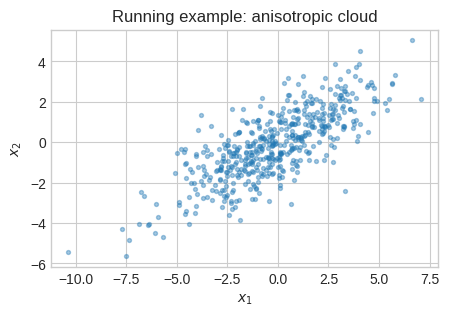

In [2]:
# A running 2-D example: an anisotropic Gaussian cloud, rotated by 30 degrees.
n = 500
raw = rng.standard_normal((n, 2)) * np.array([3.0, 1.0])   # variances 9 and 1
theta = np.deg2rad(30)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
X = raw @ R.T

Xc = X - X.mean(0)
C = (Xc.T @ Xc) / (len(X) - 1)
print("Covariance matrix C =\n", np.round(C, 2))

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.4)
ax.set_aspect("equal"); ax.set(title="Running example: anisotropic cloud", xlabel="$x_1$", ylabel="$x_2$")
plt.show()

## Part 1 · Derivation — why eigenvectors?

**Variance along a direction.** For a unit vector $w$ ($\lVert w\rVert = 1$), the
projected data are $X_c w$ and their variance is

$$ \operatorname{Var}(X_c w) \;=\; \frac{1}{n-1}\,w^\top X_c^\top X_c\, w \;=\; w^\top C\, w. $$

**PCA's first component** is the direction of *maximum* variance:

$$ w_1 \;=\; \arg\max_{\lVert w\rVert=1} \; w^\top C\, w. $$

Form the Lagrangian $\mathcal{L}(w,\lambda) = w^\top C w - \lambda\,(w^\top w - 1)$
and set $\nabla_w \mathcal{L} = 0$:

$$ 2 C w - 2\lambda w = 0 \;\;\Longrightarrow\;\; \boxed{\,C w = \lambda w\,}. $$

So the optimum is an **eigenvector** of $C$, and the variance it captures is the
eigenvalue: $w_1^\top C w_1 = \lambda_1$. The maximum-variance direction is the
**top eigenvector**; ordering eigenvectors by eigenvalue orders the components.
(The ratio $w^\top C w / w^\top w$ is the **Rayleigh quotient**; its maxima are
eigenvectors.) Subsequent PCs maximize variance *subject to orthogonality* to the
earlier ones → the remaining eigenvectors.

**SVD view.** With the thin SVD $X_c = U\Sigma V^\top$,

$$ C = \tfrac{1}{n-1} V \Sigma^\top U^\top U \Sigma V^\top = V\,\tfrac{\Sigma^2}{n-1}\,V^\top . $$

So the **right singular vectors $V$ are the principal directions**, and
$\lambda_i = \sigma_i^2/(n-1)$. (This is why numerically stable PCA uses the SVD
of $X_c$, never forms $C$ explicitly.)

### ✍️ Your turn — pen & paper
1. Show the **total variance is basis-independent**: $\sum_i \operatorname{Var}(x_i) = \operatorname{tr}(C) = \sum_i \lambda_i$.
2. Show the best rank-$k$ reconstruction has squared error $\sum_{i>k}\lambda_i$
   (this is the Eckart–Young theorem — "explained variance ratio" is $\sum_{i\le k}\lambda_i / \sum_i\lambda_i$).
3. Argue that decorrelation is automatic: in the PC basis the covariance is
   **diagonal** ($V^\top C V = \Lambda$). PCA *removes linear correlations* — remember this for Part 4.

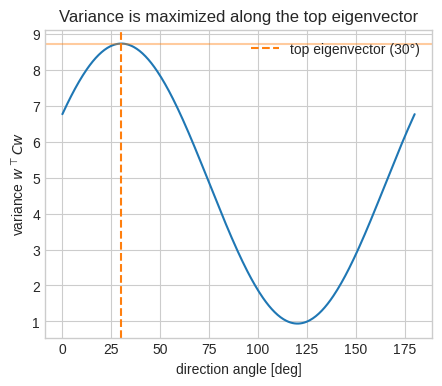

max variance 8.738  vs  top eigenvalue 8.738


In [3]:
# The Rayleigh quotient, made visible: variance vs. direction angle.
angles = np.linspace(0, np.pi, 361)
var_of_angle = np.array([np.array([np.cos(a), np.sin(a)]) @ C @ np.array([np.cos(a), np.sin(a)])
                         for a in angles])

evals, evecs = eigh(C)                 # ascending
top = evecs[:, -1]                     # top eigenvector
top_angle = np.arctan2(top[1], top[0]) % np.pi

fig, ax = plt.subplots()
ax.plot(np.rad2deg(angles), var_of_angle)
ax.axvline(np.rad2deg(top_angle), color="C1", ls="--",
           label=f"top eigenvector ({np.rad2deg(top_angle):.0f}°)")
ax.axhline(evals[-1], color="C1", alpha=.4)
ax.set(xlabel="direction angle [deg]", ylabel=r"variance $w^\top C w$",
       title="Variance is maximized along the top eigenvector")
ax.legend(); plt.show()
print(f"max variance {var_of_angle.max():.3f}  vs  top eigenvalue {evals[-1]:.3f}")

## Part 2 · PCA from scratch — and a check against `sklearn`

### ✍️ Your turn
Implement PCA two ways and confirm they agree with each other **and** with
`sklearn.decomposition.PCA`:
* `pca_eig`  — eigendecomposition of $C$ (`numpy.linalg.eigh`).
* `pca_svd`  — SVD of the centered data (`numpy.linalg.svd`).

Return the components (rows = PCs), the explained variances ($\lambda_i$), and the
scores (projections $X_c V$).

In [4]:
def pca_eig(X, k=None):
    Xc = X - X.mean(0)
    C = (Xc.T @ Xc) / (len(X) - 1)
    vals, vecs = eigh(C)                 # ascending eigenpairs
    order = np.argsort(vals)[::-1]       # -> descending
    vals, vecs = vals[order], vecs[:, order]
    k = k or X.shape[1]
    comps = vecs[:, :k].T               # (k, p): rows are PCs
    scores = Xc @ vecs[:, :k]           # (n, k)
    return comps, vals[:k], scores

def pca_svd(X, k=None):
    Xc = X - X.mean(0)
    U, S, Vt = svd(Xc, full_matrices=False)
    k = k or X.shape[1]
    comps = Vt[:k]
    expl_var = (S[:k] ** 2) / (len(X) - 1)
    scores = U[:, :k] * S[:k]           # = Xc @ Vt.T[:, :k]
    return comps, expl_var, scores

def align_sign(A, ref):
    # flip each row of A so its sign matches ref (PCs are defined only up to sign)
    s = np.sign(np.sum(A * ref, axis=1)); s[s == 0] = 1
    return A * s[:, None]

In [5]:
comps_e, var_e, sc_e = pca_eig(X)
comps_s, var_s, sc_s = pca_svd(X)
sk = PCA().fit(X)

comps_s_al = align_sign(comps_s, comps_e)
print("eig vs svd  components agree :", np.allclose(comps_e, comps_s_al, atol=1e-8))
print("eig vs svd  variances  agree :", np.allclose(var_e, var_s, atol=1e-8))
print("eig vs sklearn variances agree:", np.allclose(var_e, sk.explained_variance_, atol=1e-8))
print("eig vs sklearn components agree:",
      np.allclose(comps_e, align_sign(sk.components_, comps_e), atol=1e-6))
print("\nexplained variance ratio:", np.round(var_e / var_e.sum(), 3))

eig vs svd  components agree : True
eig vs svd  variances  agree : True
eig vs sklearn variances agree: True
eig vs sklearn components agree: True

explained variance ratio: [0.903 0.097]


In [6]:
# Two invariants worth internalizing (Part 1 problems, checked numerically):
Xc = X - X.mean(0)
C = (Xc.T @ Xc) / (len(X) - 1)
print("total variance:  trace(C) =", round(np.trace(C), 4),
      " | sum(eigenvalues) =", round(var_e.sum(), 4),
      " | sum(feature vars) =", round(Xc.var(0, ddof=1).sum(), 4))

# Eckart-Young: rank-1 reconstruction error equals the discarded eigenvalue.
comps1, _, sc1 = pca_eig(X, k=1)
X_rank1 = X.mean(0) + sc1 @ comps1
mse = ((X - X_rank1) ** 2).sum(1).mean()
print("rank-1 recon MSE =", round(mse, 4), " vs discarded eigenvalue =", round(var_e[1], 4))

total variance:  trace(C) = 9.6761  | sum(eigenvalues) = 9.6761  | sum(feature vars) = 9.6761
rank-1 recon MSE = 0.9359  vs discarded eigenvalue = 0.9378


## Part 3 · Application — recovering a hidden subspace

A classic sanity check: hide a low-dimensional structure inside a
high-dimensional space with a random rotation, then let PCA find it back.

1. Three well-separated Gaussian blobs live in **3-D**.
2. Pad with zeros to **10-D** (the last 7 coordinates carry no information).
3. Mix everything with a random rotation $A \in SO(10)$ — now *every* observed
   coordinate is an uninformative blend.
4. PCA should discover that the data really live on a 3-D subspace and recover it.

In [7]:
def random_son(n):
    # a uniformly random rotation (special orthogonal) matrix via QR
    q, r = np.linalg.qr(rng.standard_normal((n, n)))
    q *= np.sign(np.diag(r))            # fix QR sign ambiguity
    if np.linalg.det(q) < 0:
        q[:, 0] *= -1
    return q

# 3 blobs in 3-D -> pad to 10-D -> rotate into 10-D.
blobs = np.vstack([rng.standard_normal((100, 3)) + m
                   for m in ([0, 8, 0], [8, 0, 0], [0, 0, 8])])
labels_true = np.repeat([0, 1, 2], 100)
Z = np.hstack([blobs, np.zeros((300, 7))])     # (300, 10), info in first 3 cols
A = random_son(10)
S = Z @ A                                       # observed, fully mixed
print("observed data shape:", S.shape, "| true latent dim: 3")

observed data shape: (300, 10) | true latent dim: 3


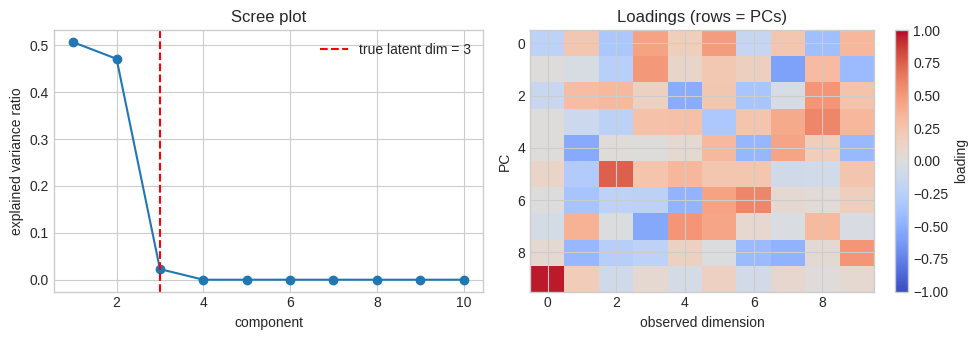

principal angles between recovered and true subspace (deg): [0. 0. 0.]


In [8]:
comps, expl, scores = pca_eig(S)
ratio = expl / expl.sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(np.arange(1, 11), ratio, "o-")
axes[0].axvline(3, color="r", ls="--", label="true latent dim = 3")
axes[0].set(title="Scree plot", xlabel="component", ylabel="explained variance ratio")
axes[0].legend()
im = axes[1].imshow(comps, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set(title="Loadings (rows = PCs)", xlabel="observed dimension", ylabel="PC")
fig.colorbar(im, ax=axes[1], label="loading"); plt.tight_layout(); plt.show()

# Did we recover the *subspace*? Compare span(top-3 PCs) with the true informative
# subspace = row space of A[:3] (the images of the 3 informative axes).
angles = subspace_angles(comps[:3].T, A[:3].T)
print("principal angles between recovered and true subspace (deg):",
      np.round(np.rad2deg(angles), 3))

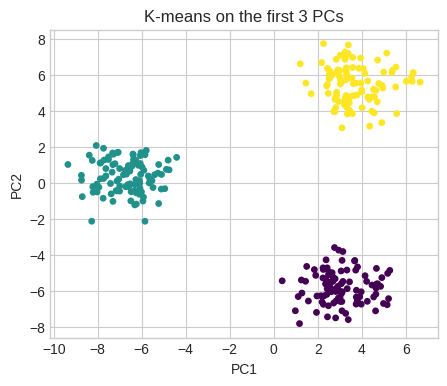

cluster recovery accuracy: 100.00%


In [9]:
# Cluster in the recovered 3-D space -> the blobs come back.
km = KMeans(n_clusters=3, n_init="auto", random_state=0).fit(scores[:, :3])
fig, ax = plt.subplots()
sc = ax.scatter(scores[:, 0], scores[:, 1], c=km.labels_, cmap="viridis", s=15)
ax.set(title="K-means on the first 3 PCs", xlabel="PC1", ylabel="PC2"); plt.show()
# agreement up to label permutation
from itertools import permutations
acc = max((np.mean([p[l] for l in km.labels_] == labels_true))
          for p in permutations(range(3)))
print(f"cluster recovery accuracy: {acc:.2%}")

## Part 4 · When PCA misleads — assumptions & failure modes

PCA makes strong assumptions. Each demo below breaks one. Read the takeaway,
then look at the picture.

### (a) Centering is not optional
PCA is about *variance*, i.e. spread **around the mean**. If you skip centering,
the first "component" is dragged toward the mean vector and no longer describes
the shape of the cloud.

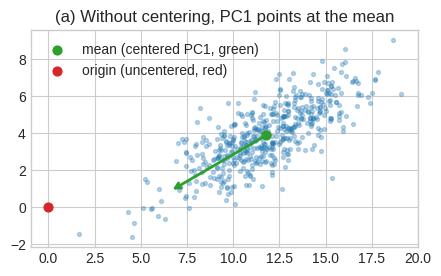

In [10]:
off = X + np.array([12, 4])            # push the cloud far from the origin
def dir_no_center(D):                  # "PCA" on the raw second moment (no centering)
    M = (D.T @ D) / (len(D) - 1)
    v, w = eigh(M); return w[:, -1]
v_raw = dir_no_center(off)
v_ok, *_ = pca_eig(off, k=1); v_ok = v_ok[0]

fig, ax = plt.subplots()
ax.scatter(off[:, 0], off[:, 1], s=8, alpha=.3)
m = off.mean(0)
ax.annotate("", xy=m + 6*v_ok, xytext=m, arrowprops=dict(arrowstyle="->", color="C2", lw=2))
ax.annotate("", xy=6*v_raw, xytext=[0, 0], arrowprops=dict(arrowstyle="->", color="C3", lw=2))
ax.scatter(*m, c="C2", s=40, zorder=5, label="mean (centered PC1, green)")
ax.scatter(0, 0, c="C3", s=40, zorder=5, label="origin (uncentered, red)")
ax.set_aspect("equal"); ax.legend(); ax.set(title="(a) Without centering, PC1 points at the mean"); plt.show()

### (b) Scale sets the answer
Variance is not unit-free. A feature measured in millivolts vs. volts, or spikes
vs. kHz, will dominate the top PC purely because of its units. When features are
incommensurable, **standardize** (z-score) first — this is PCA on the
*correlation* matrix instead of the covariance matrix.

In [11]:
# feature 0: small numeric range but real structure; feature 1: huge range, pure noise
f0 = rng.standard_normal(400) * 1.0
D = np.column_stack([f0, f0 * 0.9 + rng.standard_normal(400) * 0.3])   # correlated, informative
D = np.column_stack([D[:, 0], D[:, 1] * 100])                          # blow up feature 1's units

pc_raw, *_ = pca_eig(D, k=1)
Dz = (D - D.mean(0)) / D.std(0)
pc_std, *_ = pca_eig(Dz, k=1)
print("PC1 on raw units    :", np.round(pc_raw[0], 3), "  -> dominated by feature 1")
print("PC1 on standardized  :", np.round(pc_std[0], 3), "  -> balanced across features")

PC1 on raw units    : [0.01 1.  ]   -> dominated by feature 1
PC1 on standardized  : [0.707 0.707]   -> balanced across features


### (c) Variance ≠ importance (the biggest trap)
PCA keeps **high-variance** directions. But the direction that matters for your
question (e.g. which class a trial belongs to) can be a **low-variance** one. PCA
is unsupervised — it cannot know what you care about.

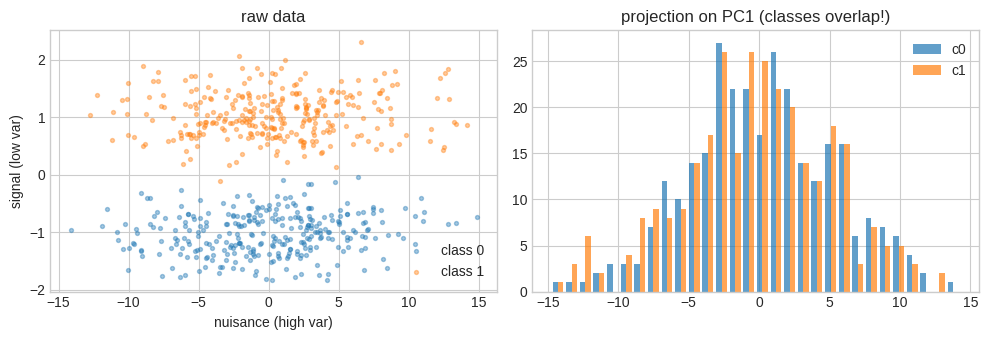

class separability  along PC1 (var 27.3): 0.11
class separability  along PC2 (var 1.2): 1.87
-> the discriminative direction is the LOW-variance PC. (Supervised: use LDA.)


In [12]:
nuisance = rng.standard_normal(600) * 5.0                     # big variance, no class info
signal = np.where(np.arange(600) < 300, -1.0, 1.0) + rng.standard_normal(600) * 0.4
y = (np.arange(600) >= 300).astype(int)
D = np.column_stack([nuisance, signal])
comps, expl, scores = pca_eig(D)

def separability(proj, y):             # standardized mean difference between classes
    return abs(proj[y == 0].mean() - proj[y == 1].mean()) / proj.std()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for c in (0, 1):
    axes[0].scatter(D[y == c, 0], D[y == c, 1], s=8, alpha=.4, label=f"class {c}")
axes[0].set(title="raw data", xlabel="nuisance (high var)", ylabel="signal (low var)"); axes[0].legend()
axes[1].hist([scores[y == 0, 0], scores[y == 1, 0]], bins=30, label=["c0", "c1"], alpha=.7)
axes[1].set(title="projection on PC1 (classes overlap!)"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"class separability  along PC1 (var {expl[0]:.1f}): {separability(scores[:,0], y):.2f}")
print(f"class separability  along PC2 (var {expl[1]:.1f}): {separability(scores[:,1], y):.2f}")
print("-> the discriminative direction is the LOW-variance PC. (Supervised: use LDA.)")

### (d) PCA is linear — nonlinear geometry survives it
PCA can only rotate and project. If the structure is curved (a ring, a spiral,
a manifold), no linear projection untangles it. This is the motivation for
**kernel PCA / UMAP (W06)**.

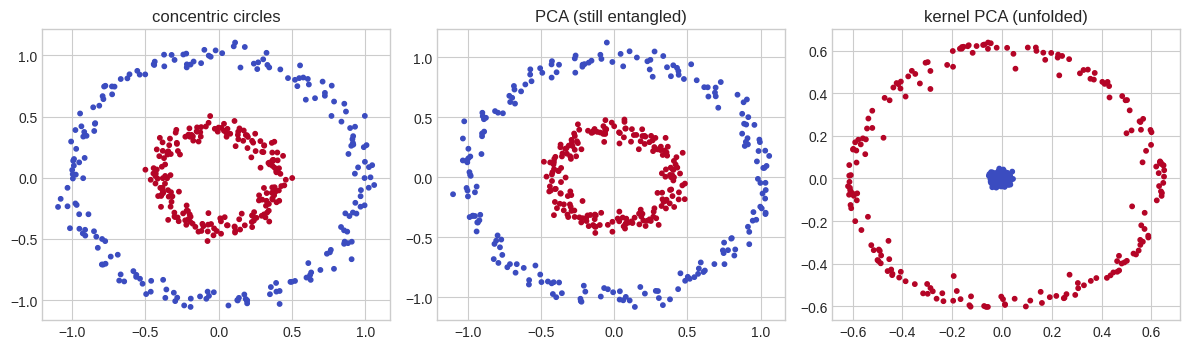

Linear PCA cannot separate the rings; a nonlinear method can -> see W06 (UMAP).


In [13]:
Xc_, yc = make_circles(n_samples=400, factor=0.4, noise=0.05, random_state=0)
lin = PCA(n_components=2).fit_transform(Xc_)
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=10).fit_transform(Xc_)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, data, title in zip(axes, [Xc_, lin, kpca],
                           ["concentric circles", "PCA (still entangled)", "kernel PCA (unfolded)"]):
    ax.scatter(data[:, 0], data[:, 1], c=yc, cmap="coolwarm", s=10); ax.set(title=title)
plt.tight_layout(); plt.show()
print("Linear PCA cannot separate the rings; a nonlinear method can -> see W06 (UMAP).")

### (e) Uncorrelated ≠ independent
PCA *decorrelates* (Part 1, problem 3): it removes **second-order** dependence.
But uncorrelated variables can still be statistically dependent. When sources are
non-Gaussian, you need higher-order structure to separate them — that is
**ICA (W05)**. Whitening with PCA is in fact the standard *first step* of ICA.

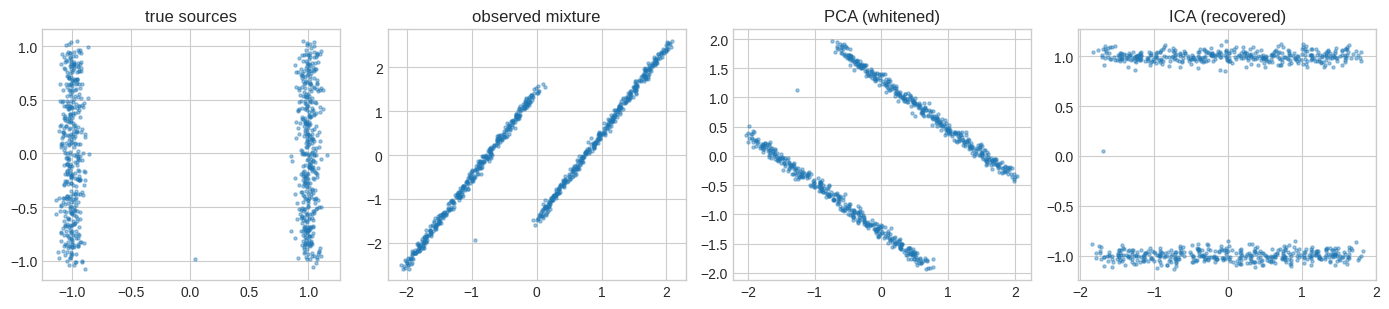

PCA whitens but leaves the sources rotated/mixed; ICA recovers them -> see W05.


In [14]:
# two independent non-Gaussian sources, linearly mixed
t = np.linspace(0, 8*np.pi, 800)
s1 = np.sign(np.sin(1.5 * t))                      # square wave
s2 = (np.mod(t, 2*np.pi) - np.pi) / np.pi          # sawtooth
Ssrc = np.column_stack([s1, s2]) + rng.standard_normal((800, 2)) * 0.05
Mix = Ssrc @ np.array([[1.0, 1.0], [0.5, 2.0]]).T

pca_axes = PCA(whiten=True).fit_transform(Mix)      # decorrelated / whitened
ica_axes = FastICA(n_components=2, random_state=0, whiten="unit-variance").fit_transform(Mix)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, d, title in zip(axes, [Ssrc, Mix, pca_axes, ica_axes],
                        ["true sources", "observed mixture", "PCA (whitened)", "ICA (recovered)"]):
    ax.scatter(d[:, 0], d[:, 1], s=5, alpha=.4); ax.set(title=title)
plt.tight_layout(); plt.show()
print("PCA whitens but leaves the sources rotated/mixed; ICA recovers them -> see W05.")

## Wrap-up & where this goes next

* PCA = **eigendecomposition of the covariance matrix** = variance-maximizing
  orthogonal projection = truncated SVD of the centered data. Three views, one object.
* It **decorrelates** and gives the optimal *linear* low-rank reconstruction
  (Eckart–Young), but it is blind to (b) scale, (c) what you care about,
  (d) nonlinearity, and (e) higher-order/independence structure.

**Covariance spine, revisited.** PCA diagonalizes the spatial covariance $C$.
Next to it: the **power spectrum** (W02) is the Fourier transform of the
*temporal* autocovariance, and an **AR model** (W03) is a parametric model of the
same autocovariance. Whitening bridges to **ICA** (W05); nonlinearity bridges to
**UMAP** (W06).

### ✍️ Open exercise — your own data
Take a dataset of your choice (your project data, or a public neural dataset) and:
1. Standardize if the features are incommensurable (Part 4b) and state why.
2. Scree plot — how many components until 90% variance? Is there an "elbow"?
3. Inspect the top loadings — what do PC1/PC2 *mean* in terms of the original features?
4. If you have labels, check whether the discriminative direction is actually a
   top PC (Part 4c). If not, what does that tell you?